In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
%matplotlib inline

In [2]:
zipcodes = gpd.read_file('../../geospatial-BigECire/data/zipcodes.geojson')
zipcodes.head()

Can't load requested DLL: C:\Users\erics\anaconda3\envs\geospatial\Library\lib\gdalplugins\gdal_FITS.dll
127: The specified procedure could not be found.

Can't load requested DLL: C:\Users\erics\anaconda3\envs\geospatial\Library\lib\gdalplugins\gdal_FITS.dll
127: The specified procedure could not be found.

Can't load requested DLL: C:\Users\erics\anaconda3\envs\geospatial\Library\lib\gdalplugins\gdal_GRIB.dll
127: The specified procedure could not be found.

Can't load requested DLL: C:\Users\erics\anaconda3\envs\geospatial\Library\lib\gdalplugins\gdal_GRIB.dll
127: The specified procedure could not be found.

Can't load requested DLL: C:\Users\erics\anaconda3\envs\geospatial\Library\lib\gdalplugins\gdal_HDF4.dll
127: The specified procedure could not be found.

Can't load requested DLL: C:\Users\erics\anaconda3\envs\geospatial\Library\lib\gdalplugins\gdal_HDF4.dll
127: The specified procedure could not be found.

Can't load requested DLL: C:\Users\erics\anaconda3\envs\geospatial\Lib

,zip,objectid,po_name,shape_stlength,shape_starea,geometry
0,37115,1,MADISON,178783.02488886821,596553400.57885742,"MULTIPOLYGON (((-86.68725 36.31821, -86.68722 ..."
1,37216,3,NASHVILLE,75820.997821400058,188884682.28344727,"MULTIPOLYGON (((-86.73451 36.23774, -86.73425 ..."
2,37204,9,NASHVILLE,93180.292250425613,200664795.51708984,"MULTIPOLYGON (((-86.77914 36.13424, -86.77923 ..."
3,37027,11,BRENTWOOD,159760.6942933173,174978422.04101562,"MULTIPOLYGON (((-86.81258 36.06319, -86.81263 ..."
4,37064,18,FRANKLIN,28995.828320601937,46969608.005737305,"MULTIPOLYGON (((-87.02197 36.01200, -87.02140 ..."


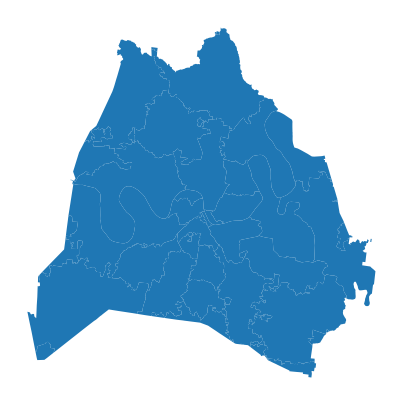

In [5]:
fig, ax = plt.subplots(figsize=(5,5))
zipcodes.plot(ax = ax)
ax.axis('off');

In [9]:
zipcodes.zip = zipcodes.zip.astype(int)

In [13]:
zipcodes.shape

(56, 6)

In [10]:
missed_calc_zip_test = pd.read_csv('../data/missed_calc_zip_test.csv')
missed_calc_zip_test.head()

,Unnamed: 0,trash_hauler,zip,address,date,num_of_fines,fines_amount
0,4,METRO,37201,200 2Nd Ave S,3,2,400
1,5,METRO,37201,217 2Nd Ave S,6,5,1000
2,8,METRO,37201,317 Broadway,2,1,200
3,14,METRO,37203,1005 9Th Ave S,2,1,200
4,20,METRO,37203,1009 Southside Ave B,2,1,200


In [16]:
missed_calc_zip_test = missed_calc_zip_test.drop(columns = 'Unnamed: 0')

In [18]:
missed_calc_zip = missed_calc_zip_test.groupby(['trash_hauler', 'zip'], as_index=False).sum()

In [19]:
metro = missed_calc_zip.loc[missed_calc_zip.trash_hauler == 'METRO']
red_river = missed_calc_zip.loc[missed_calc_zip.trash_hauler == 'RED RIVER']
waste_ind = missed_calc_zip.loc[missed_calc_zip.trash_hauler == 'WASTE IND']

In [20]:
waste_ind.shape

(9, 6)

In [21]:
metro_merge =  pd.merge(left = zipcodes, right = metro, left_on = 'zip', right_on = 'zip', how='left')
red_river_merge =  pd.merge(left = zipcodes, right = red_river, left_on = 'zip', right_on = 'zip', how='left')
waste_ind_merge = pd.merge(left = zipcodes, right = waste_ind, left_on = 'zip', right_on = 'zip', how='left')
waste_ind_merge.shape

(56, 11)

In [22]:
missed_zips = pd.concat([metro_merge,red_river_merge,waste_ind_merge])
missed_zips.shape

(168, 11)

In [23]:
missed_zips.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 168 entries, 0 to 55
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   zip             168 non-null    int32   
 1   objectid        168 non-null    object  
 2   po_name         168 non-null    object  
 3   shape_stlength  168 non-null    object  
 4   shape_starea    168 non-null    object  
 5   geometry        168 non-null    geometry
 6   trash_hauler    53 non-null     object  
 7   address         53 non-null     object  
 8   date            53 non-null     float64 
 9   num_of_fines    53 non-null     float64 
 10  fines_amount    53 non-null     float64 
dtypes: float64(3), geometry(1), int32(1), object(6)
memory usage: 15.1+ KB


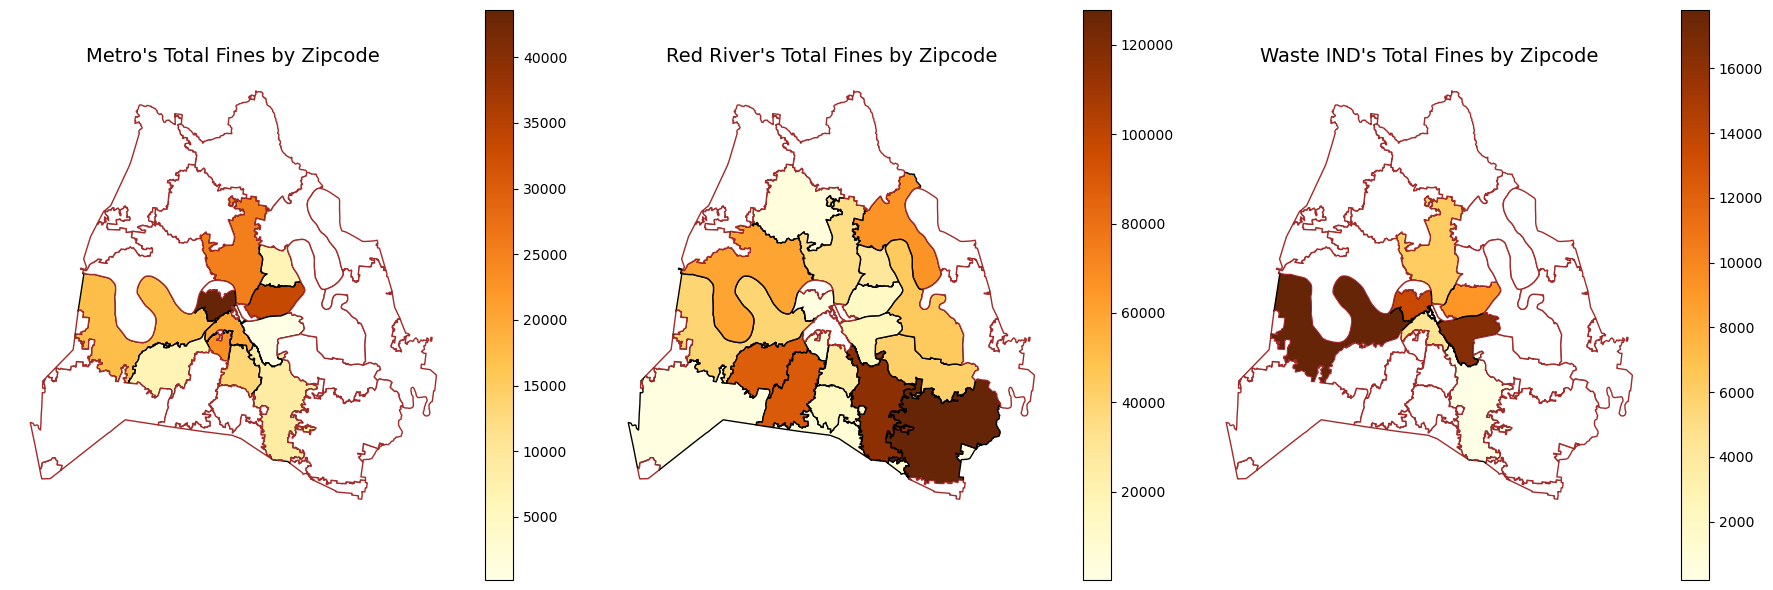

In [60]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

metro_merge.plot(column = 'fines_amount',  cmap = 'YlOrBr', edgecolor = 'black', legend = True, ax = axes[0], missing_kwds={ "color": "white", "edgecolor": "brown", "hatch": "0", "label": "Missing values"})
axes[0].set_title("Metro's Total Fines by Zipcode", fontsize = 14)
axes[0].axis('off')

red_river_merge.plot(column = 'fines_amount',  cmap = 'YlOrBr', edgecolor = 'black', legend = True, ax = axes[1], missing_kwds={ "color": "white", "edgecolor": "brown", "hatch": "0", "label": "Missing values"})
axes[1].set_title("Red River's Total Fines by Zipcode", fontsize = 14)
axes[1].axis('off')

waste_ind_merge.plot(column = 'fines_amount',  cmap = 'YlOrBr', edgecolor = 'black', legend = True, ax = axes[2], missing_kwds={ "color": "white", "edgecolor": "brown", "hatch": "0", "label": "Missing values"})
axes[2].set_title("Waste IND's Total Fines by Zipcode", fontsize = 14)
axes[2].axis('off')

plt.tight_layout()
plt.savefig("TotalFines.png", dpi=300, bbox_inches='tight')

In [38]:
complaints = pd.read_csv('../data/q1.csv').drop(columns = 'Unnamed: 0')
complaints

,request,total,missed_pickup,diff
0,Trash - Curbside/Alley Missed Pickup,15028,10329,4699
1,Trash - Backdoor,2629,2017,612
2,Trash Collection Complaint,2312,695,1617
3,Damage to Property,257,3,254


In [45]:
complaints_norm = complaints
complaints_norm['missed_pickup_percent'] = complaints_norm.missed_pickup / complaints_norm.total
complaints_norm['diff_percent'] = complaints_norm['diff'] / complaints_norm.total
complaints_norm = complaints_norm.drop(columns = ['total', 'missed_pickup',	'diff'])
complaints_norm


,request,missed_pickup_percent,diff_percent
0,Trash - Curbside/Alley Missed Pickup,0.687317,0.312683
1,Trash - Backdoor,0.767212,0.232788
2,Trash Collection Complaint,0.300606,0.699394
3,Damage to Property,0.011673,0.988327


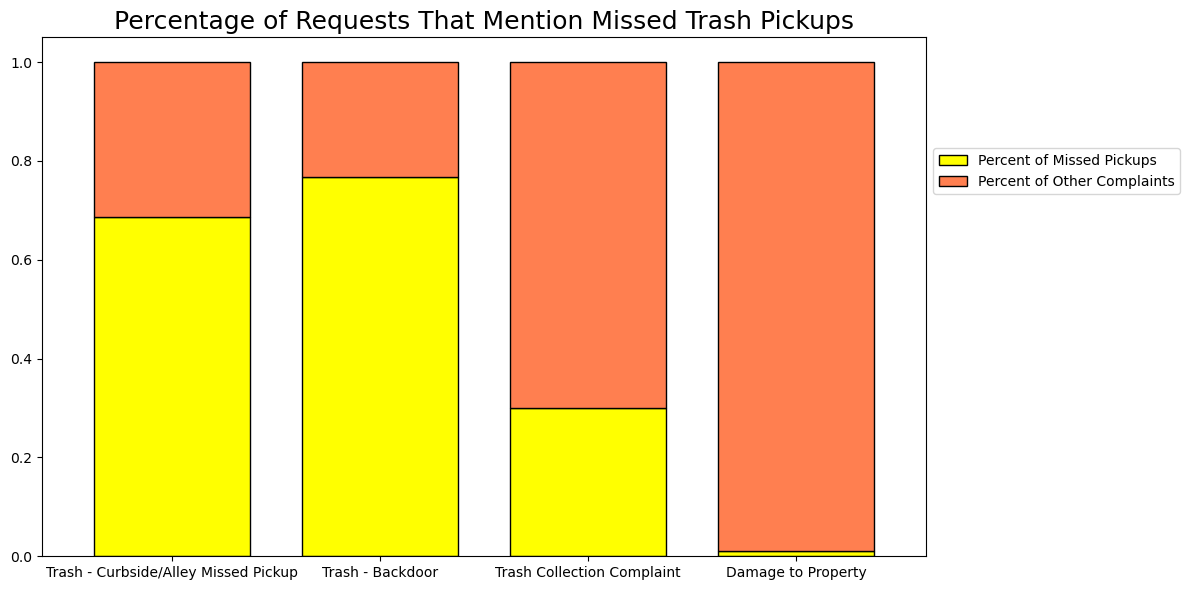

In [59]:
complaints_norm.plot(x='request', kind = 'bar', stacked = True, color = ['yellow', 'coral'], edgecolor = 'black', width = 0.75, figsize=(12, 6))
plt.title('Percentage of Requests That Mention Missed Trash Pickups', fontsize = 18)
plt.xticks(rotation = 0)
plt.legend(labels=['Percent of Missed Pickups', 'Percent of Other Complaints'],bbox_to_anchor = (1, 0.8), loc = 'upper left')
plt.xlabel('')
plt.tight_layout();
plt.savefig("PercentageofRequests.png", dpi=300, bbox_inches='tight')